# <b> cf.가중치 최적화(Optimization) 기법

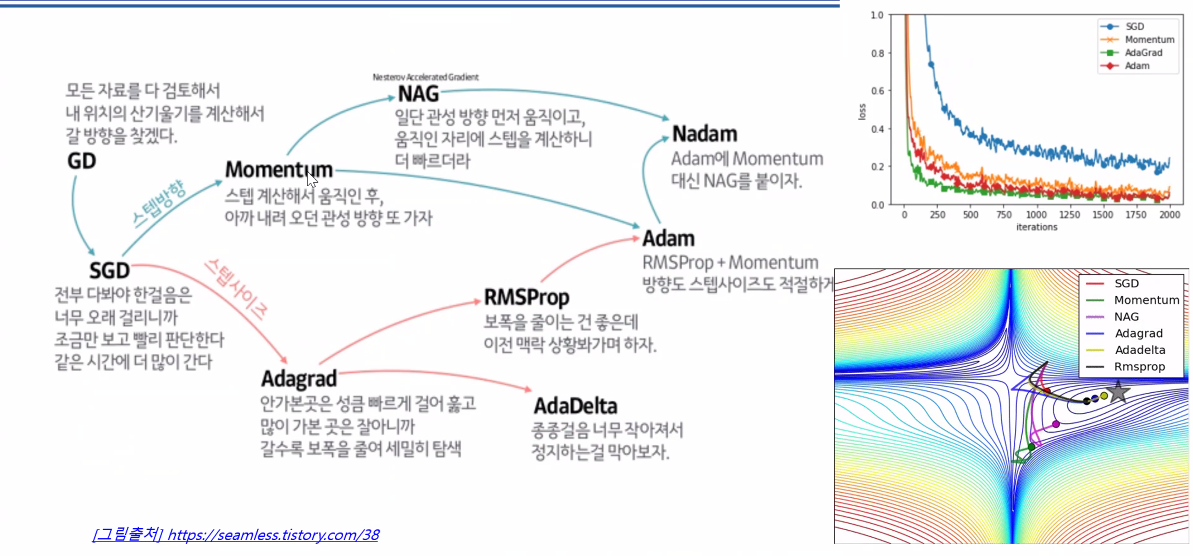

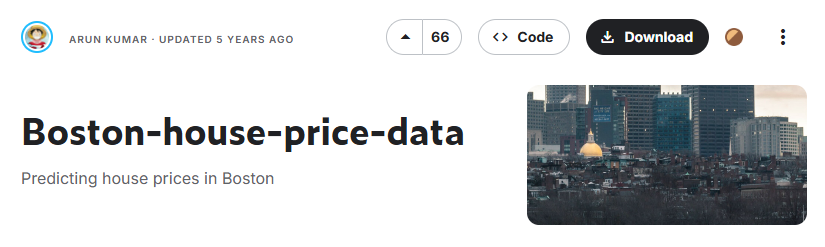
https://www.kaggle.com/datasets/arunjathari/bostonhousepricedata

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#--------------------------------------------------------------- IML 모델
from xgboost import XGBRegressor
#--------------------------------------------------------------- DL 모델
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#--------------------------------------------------------------- 평가
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split



import warnings
warnings.filterwarnings('ignore')

sns.set()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b> Data Load

In [2]:
df = pd.read_csv("../Machine_Learning/datas/06.House/Boston-house-price-data.csv")
df.head(2)
df.columns = df.columns.str.lower()
df.head(2)
df.info()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.9,9.14,21.6


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.9,9.14,21.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


<pre>- CRIM: per capita crime rate by town
- ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS: proportion of non-retail business acres per town
- CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX: nitric oxides concentration (parts per 10 million)
    1https://archive.ics.uci.edu/ml/datasets/Housing 123 20.2. Load the Dataset 124
- RM: average number of rooms per dwelling
- AGE: proportion of owner-occupied units built prior to 1940
- DIS: weighted distances to ﬁve Boston employment centers
- RAD: index of accessibility to radial highways
- TAX: full-value property-tax rate per $10,000
- PTRATIO: pupil-teacher ratio by town 12. B: 1000(Bk−0.63)2 
    where Bk is the proportion of blacks by town 13. LSTAT: % lower status of the population
- MEDV: Median value of owner-occupied homes in $1000s
- We can see that the input attributes have a mixture of units.m

<font size=4><b> 보스턴 주택 가격 데이터셋 피처 설명</font>

| 피처명 | 단위 | 비고 | 설명 |
| :--- | :--- | :--- | :--- |
| **CRIM** | | 범죄 발생률 | 타운별 1인당 범죄 발생률 |
| **ZN** | % | 주거 구역 비중 | 25,000평방피트를 초과하는 거주 지역의 비율 |
| **INDUS** | % | 비상업 지구 비중 | 도시당 비소매 상업 지역의 비율 |
| **CHAS** | | 더미 변수 | 찰스강 인접 여부 (강 경계에 위치하면 1, 아니면 0) |
| **NOX** | ppm | 대기 오염 수준 | 일산화질소 농도 (1,000만 부당 부피) |
| **RM** | 개 | 주택 크기 지표 | 주택당 평균 방의 개수 |
| **AGE** | % | 노후 주택 비중 | 1940년 이전에 건축된 소유주 거주 주택의 비율 |
| **DIS** | | 직주 근접성 | 5개의 보스턴 고용 센터까지의 가중 거리 |
| **RAD** | | 교통 편의성 | 방사형 고속도로 접근성 지수 |
| **TAX** | \$ | 세금 수준 | \$10,000당 풀 가치 재산세율 |
| **PTRATIO** | 명 | 교육 환경 | 도시별 학생-교사 비율 |
| **B** | | 인구 통계 지표 | $1000(Bk - 0.63)^2$ (Bk는 도시별 흑인 비율) |
| **LSTAT** | % | 사회경제적 지표 | 하위 계층 인구의 비율(%) |
| **MEDV** | \$ | **타겟 변수 (Target)** | 본인 소유 주택 가격의 중앙값 (\$1000 단위) |

# <b> 머신러닝(회귀) 모델 점수

In [3]:
y = df['medv']
X = df.drop('medv', axis=1)
print(X.shape,  y.shape)

X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )
print(X80.shape,X20.shape,y80.shape,y20.shape)

(506, 13) (506,)
(379, 13) (127, 13) (379,) (127,)


In [4]:
model = XGBRegressor(random_state=4567)

model.fit(X80, y80)
pred = model.predict(X20)

mse  = mean_squared_error(y20, pred)
rmse = np.sqrt(mse)

print(f"mse:{mse:.4f}\t rmse:{rmse:.4f}")

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


mse:9.0452	 rmse:3.0075


# <b> 딥러닝 모델 점수

### <b> 1. 라이브러리 준비 및 환경 설정

In [5]:
#----------------------------------------------------------------------------------   DL 모델
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#----------------------------------------------------------------------------------  평가
from sklearn.metrics  import accuracy_score,      f1_score

### <b> 2. 딥러닝 회귀 모델 구조 설계 (Model Build)

In [6]:
model = Sequential([
    Dense(10, activation="relu", input_dim=13 ), # ---- input layer
    Dense(16, activation="relu"               ), # ---- hidden Layer 3
    Dense(24, activation="relu"               ),
    Dense(8,  activation="relu"               ),
    Dense(1,                                  )  # ---- output layer
])

### <b> 3. 모델 컴파일 및 학습 규칙 설정 (Compile)

In [7]:
# --------------- 컴파일 안에 L,O,M 3개 넣어야함 (L_loss, O_optimizer, M_metrics)
model.compile(loss="mse", optimizer="adam", metrics=["mse"]) 

### <b> 4. 모델 요약 및 파람즈(Params) 확인

In [8]:
model.summary()


# param # : AI 모델이 학습을 통해 기억해야 할 '가중치(Weight)와 편향(Bias)의 총 개수 (공식의 개수)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │             140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 933 (3.64 KB)

 Trainable params: 933 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

### <b> 5. 딥러닝 모델 학습 실행 (Fit)

In [9]:
res = model.fit(   X80, y80,   epochs=50,   validation_data =(X20,y20)   )
res

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 692.6402 - mse: 692.6402 - val_loss: 594.6077 - val_mse: 594.6077
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 612.3295 - mse: 612.3295 - val_loss: 577.7718 - val_mse: 577.7718
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 599.5944 - mse: 599.5944 - val_loss: 570.2206 - val_mse: 570.2206
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 594.4803 - mse: 594.4803 - val_loss: 564.1804 - val_mse: 564.1804
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 585.3050 - mse: 585.3050 - val_loss: 546.5814 - val_mse: 546.5814
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 541.2850 - mse: 541.2850 - val_loss: 467.5373 - val_mse: 467.5373
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 435.6786 - mse: 435.6786 - val_loss: 347.2347 - val_mse: 347.2347
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 309.7342 - mse: 309.7342 - val_loss: 226.3309 - val_mse: 226.3309
Epoch 9

### <b> 6. 최종 성능 평가 및 오차(RMSE) 분석

In [10]:
loss,mse = model.evaluate(X20,y20)
print("==================================================== ")
print(f" mse : {mse:.4f}, loss : {loss:.4f},      rmse : {np.sqrt(mse):.4f}")
print("==================================================== ")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 39.8379 - mse: 39.8379 
 mse : 39.8379, loss : 39.8379,      rmse : 6.3117


> <b><big>  cf. ML 모델 돌렸을때 결과 </b></big> (이전 회귀 ML 모델 결과임) <br>

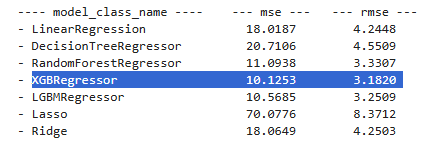

### <b> 학습 이력(History) 데이터 원본 확인

In [14]:
res.history
# dictionary 형태 확인 가능

{'loss': [692.6401977539062,
  612.3295288085938,
  599.5944213867188,
  594.4802856445312,
  585.3049926757812,
  541.2849731445312,
  435.6785888671875,
  309.7341613769531,
  200.36436462402344,
  133.83197021484375,
  87.86014556884766,
  68.5676040649414,
  68.29534149169922,
  65.1351547241211,
  65.51822662353516,
  65.98319244384766,
  62.53068923950195,
  63.62287521362305,
  62.28535079956055,
  62.133914947509766,
  62.184059143066406,
  60.82905960083008,
  62.49964904785156,
  62.4111442565918,
  60.526702880859375,
  60.19028091430664,
  59.63240051269531,
  59.33058166503906,
  58.99471664428711,
  58.66808319091797,
  59.37983322143555,
  62.445133209228516,
  59.639007568359375,
  59.483123779296875,
  58.23750686645508,
  56.93050765991211,
  56.57265853881836,
  56.86952590942383,
  56.10368728637695,
  55.53639221191406,
  55.47378158569336,
  54.52521896362305,
  54.69609069824219,
  54.98357009887695,
  55.464725494384766,
  53.634193420410156,
  53.20331954956055

### <b> 학습 이력(History) 데이터 구조(keys) 확인

In [12]:
res.history.keys()

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])

### <b> 학습 결과 시각화 (Loss & MSE 그래프)

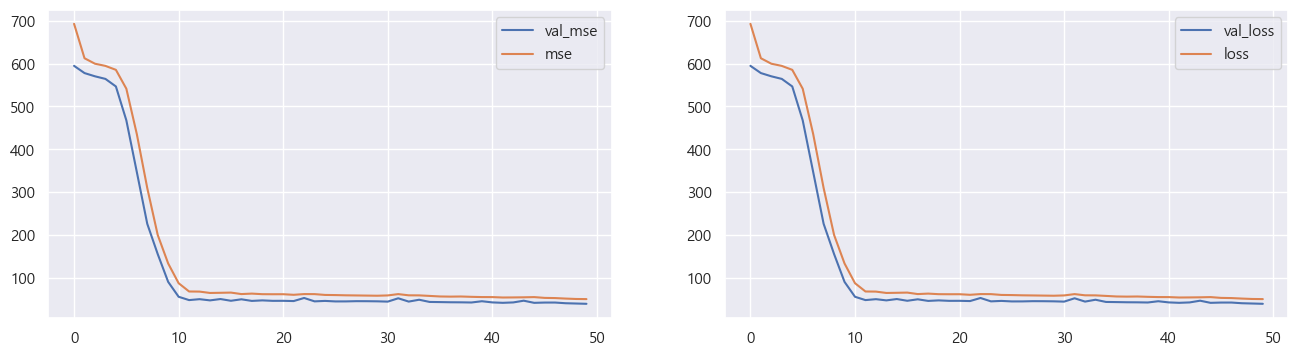

In [13]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_mse"]
acc  = res.history["mse"]
plt.plot(range(50), vacc , label="val_mse")
plt.plot(range(50), acc  , label="mse")
plt.legend()
plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(50),vloss , label="val_loss")
plt.plot(range(50),loss  , label="loss")
plt.legend()
plt.show();